## Topic:Design and Implement an AI-Powered System that leverages NLP to detect Adverse Drug Events(ADE)

## Name:Aadith P
## Rollno:CB.AI.P2DSC25001

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/ADEGuard"
os.makedirs(project_path, exist_ok=True)

os.listdir("/content/drive/MyDrive")


['Colab Notebooks', 'Vasundhara.pdf', 'ADEGuard']

In [ ]:
os.listdir("/content/drive/MyDrive/ADEGuard")


['file_dsrpc_2.zip']

In [ ]:
import os

base_path = "/content/drive/MyDrive/ADEGuard"
extract_path = os.path.join(base_path, "raw_data")

os.makedirs(extract_path, exist_ok=True)

os.listdir(base_path)


['file_dsrpc_2.zip', 'raw_data']

In [ ]:
import zipfile
import os

zip_file_path = "/content/drive/MyDrive/ADEGuard/file_dsrpc_2.zip"
extract_path = "/content/drive/MyDrive/ADEGuard/raw_data"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)



['download_files_for_participants']

In [ ]:
import os

base_path = "/content/drive/MyDrive/ADEGuard/raw_data/download_files_for_participants"
os.listdir(base_path)


['Annotation Guidelines.md',
 'data',
 'Evaluation Criteria.docx',
 'Problem Statement.docx']

In [ ]:
import os

data_path = "/content/drive/MyDrive/ADEGuard/raw_data/download_files_for_participants/data"
os.listdir(data_path)


['2020VAERSData.zip',
 '2021VAERSData.zip',
 '2022VAERSData.zip',
 '2023VAERSData.zip',
 '2024VAERSData.zip',
 '2025VAERSData.zip']

In [ ]:
import zipfile
import os

data_path = "/content/drive/MyDrive/ADEGuard/raw_data/download_files_for_participants/data"

for zip_file in os.listdir(data_path):
    if zip_file.endswith(".zip"):
        year = zip_file.replace(".zip", "")
        year_folder = os.path.join(data_path, year)
        os.makedirs(year_folder, exist_ok=True)

        zip_path = os.path.join(data_path, zip_file)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(year_folder)

print("Unzipping completed!")
os.listdir(data_path)


Unzipping completed!


['2020VAERSData.zip',
 '2021VAERSData.zip',
 '2022VAERSData.zip',
 '2023VAERSData.zip',
 '2024VAERSData.zip',
 '2025VAERSData.zip',
 '2020VAERSData',
 '2021VAERSData',
 '2022VAERSData',
 '2023VAERSData',
 '2024VAERSData',
 '2025VAERSData']

In [ ]:
os.listdir("/content/drive/MyDrive/ADEGuard/raw_data/download_files_for_participants/data/2020VAERSData")


['2020VAERSDATA.csv', '2020VAERSSYMPTOMS.csv', '2020VAERSVAX.csv']

In [ ]:
import pandas as pd

base_2020 = "/content/drive/MyDrive/ADEGuard/raw_data/download_files_for_participants/data/2020VAERSData"

vaers_2020 = pd.read_csv(f"{base_2020}/2020VAERSDATA.csv", encoding="latin-1")
symptoms_2020 = pd.read_csv(f"{base_2020}/2020VAERSSYMPTOMS.csv", encoding="latin-1")
vax_2020 = pd.read_csv(f"{base_2020}/2020VAERSVAX.csv", encoding="latin-1")

vaers_2020.shape, symptoms_2020.shape, vax_2020.shape



/tmp/ipython-input-3941232859.py:5: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  vaers_2020 = pd.read_csv(f"{base_2020}/2020VAERSDATA.csv", encoding="latin-1")


((51002, 36), (62885, 12), (61314, 9))

In [ ]:
vaers_2020[['VAERS_ID', 'AGE_YRS', 'SEX', 'SYMPTOM_TEXT']].head()


,VAERS_ID,AGE_YRS,SEX,SYMPTOM_TEXT
0,810053,73.0,F,Extreme shivering for approx. 5 hours then fev...
1,855017,55.0,F,Symptoms occurred almost immediately- aching j...
2,855018,68.0,F,"Extreme pain, muscle weakness in right arm so ..."
3,855019,50.0,F,SORENESS IN THE AREA. ITCHING AND RASH
4,855020,67.0,F,"sore arm, fever 101 , chills, and aching musc..."


In [ ]:
# Select only symptom columns
symptom_cols = [col for col in symptoms_2020.columns if col.startswith("SYMPTOM")]

# Group by VAERS_ID and collect symptoms into a list
symptoms_grouped = (
    symptoms_2020
    .set_index('VAERS_ID')[symptom_cols]
    .apply(lambda row: [s for s in row if pd.notna(s)], axis=1)
    .reset_index(name='structured_symptoms')
)

symptoms_grouped.head()


,VAERS_ID,structured_symptoms
0,275438,"[Autopsy, 22.1, Cor pulmonale acute, 22.1, Cor..."
1,275438,"[Echocardiogram abnormal, 22.1, Glassy eyes, 2..."
2,275438,"[Right ventricular enlargement, 22.1, Seizure,..."
3,275438,"[Tremor, 22.1]"
4,340381,"[Injection site erythema, 23.0, Injection site..."


In [ ]:
vax_grouped = (
    vax_2020
    .groupby('VAERS_ID')
    .agg({
        'VAX_NAME': list,
        'VAX_MANU': list,
        'VAX_TYPE': list
    })
    .reset_index()
)

vax_grouped.head()


,VAERS_ID,VAX_NAME,VAX_MANU,VAX_TYPE
0,275438,[HPV (GARDASIL)],[MERCK & CO. INC.],[HPV4]
1,340381,"[MENINGOCOCCAL CONJUGATE (MENACTRA), TDAP (NO ...","[SANOFI PASTEUR, UNKNOWN MANUFACTURER]","[MNQ, TDAP]"
2,361824,[INFLUENZA (SEASONAL) (FLUZONE HIGH-DOSE QUADR...,[SANOFI PASTEUR],[FLU4]
3,371224,[ZOSTER LIVE (ZOSTAVAX)],[MERCK & CO. INC.],[VARZOS]
4,386005,[ZOSTER LIVE (ZOSTAVAX)],[MERCK & CO. INC.],[VARZOS]


In [ ]:
merged_2020 = (
    vaers_2020
    .merge(symptoms_grouped, on='VAERS_ID', how='left')
    .merge(vax_grouped, on='VAERS_ID', how='left')
)

merged_2020.shape


(66034, 40)

In [ ]:
merged_2020[['VAERS_ID', 'AGE_YRS', 'SYMPTOM_TEXT', 'structured_symptoms', 'VAX_NAME']].head()


,VAERS_ID,AGE_YRS,SYMPTOM_TEXT,structured_symptoms,VAX_NAME
0,810053,73.0,Extreme shivering for approx. 5 hours then fev...,"[Asthenia, 22.1, Chills, 22.1, Headache, 22.1,...",[INFLUENZA (SEASONAL) (FLUZONE HIGH-DOSE)]
1,810053,73.0,Extreme shivering for approx. 5 hours then fev...,"[Pain, 22.1, Pyrexia, 22.1]",[INFLUENZA (SEASONAL) (FLUZONE HIGH-DOSE)]
2,855017,55.0,Symptoms occurred almost immediately- aching j...,"[Arthralgia, 22.1, Chills, 22.1, Injection sit...",[ZOSTER (SHINGRIX)]
3,855018,68.0,"Extreme pain, muscle weakness in right arm so ...","[Chills, 22.1, Fatigue, 22.1, Hypertension, 22...",[VACCINE NOT SPECIFIED (OTHER)]
4,855018,68.0,"Extreme pain, muscle weakness in right arm so ...","[Muscular weakness, 22.1, Pain in extremity, 2...",[VACCINE NOT SPECIFIED (OTHER)]


In [ ]:
# Keep only SYMPTOM columns (not SYMPTOMVERSION)
symptom_name_cols = [
    col for col in symptoms_2020.columns
    if col.startswith("SYMPTOM") and not col.startswith("SYMPTOMVERSION")
]

symptom_name_cols


['SYMPTOM1', 'SYMPTOM2', 'SYMPTOM3', 'SYMPTOM4', 'SYMPTOM5']

In [ ]:
symptoms_grouped = (
    symptoms_2020
    .set_index('VAERS_ID')[symptom_name_cols]
    .stack()                      # convert columns to rows
    .dropna()                     # remove empty values
    .groupby(level=0)             # group by VAERS_ID
    .apply(list)                  # collect all symptoms
    .reset_index(name='structured_symptoms')
)

symptoms_grouped.head()


,VAERS_ID,structured_symptoms
0,275438,"[Autopsy, Cor pulmonale acute, Coronary artery..."
1,340381,"[Injection site erythema, Injection site pain,..."
2,361824,"[Rash, Urticaria, Vaccination complication]"
3,371224,[Facial paralysis]
4,386005,[Post herpetic neuralgia]


In [ ]:
merged_2020 = (
    vaers_2020
    .merge(symptoms_grouped, on='VAERS_ID', how='left')
    .merge(vax_grouped, on='VAERS_ID', how='left')
)

merged_2020.shape


(51002, 40)

In [ ]:
merged_2020[['VAERS_ID', 'AGE_YRS', 'SYMPTOM_TEXT', 'structured_symptoms', 'VAX_NAME']].head()


,VAERS_ID,AGE_YRS,SYMPTOM_TEXT,structured_symptoms,VAX_NAME
0,810053,73.0,Extreme shivering for approx. 5 hours then fev...,"[Asthenia, Chills, Headache, Heart rate increa...",[INFLUENZA (SEASONAL) (FLUZONE HIGH-DOSE)]
1,855017,55.0,Symptoms occurred almost immediately- aching j...,"[Arthralgia, Chills, Injection site pain, Pyre...",[ZOSTER (SHINGRIX)]
2,855018,68.0,"Extreme pain, muscle weakness in right arm so ...","[Chills, Fatigue, Hypertension, Hypoaesthesia,...",[VACCINE NOT SPECIFIED (OTHER)]
3,855019,50.0,SORENESS IN THE AREA. ITCHING AND RASH,"[Pain, Pruritus, Rash]",[ZOSTER (SHINGRIX)]
4,855020,67.0,"sore arm, fever 101 , chills, and aching musc...","[Chills, Influenza like illness, Myalgia, Pain...",[ZOSTER (SHINGRIX)]


In [ ]:
def load_and_merge_vaers(year):
    base_path = f"/content/drive/MyDrive/ADEGuard/raw_data/download_files_for_participants/data/{year}VAERSData"

    vaers = pd.read_csv(f"{base_path}/{year}VAERSDATA.csv", encoding="latin-1")
    symptoms = pd.read_csv(f"{base_path}/{year}VAERSSYMPTOMS.csv", encoding="latin-1")
    vax = pd.read_csv(f"{base_path}/{year}VAERSVAX.csv", encoding="latin-1")

    symptom_cols = [
        c for c in symptoms.columns
        if c.startswith("SYMPTOM") and not c.startswith("SYMPTOMVERSION")
    ]

    symptoms_grouped = (
        symptoms
        .set_index('VAERS_ID')[symptom_cols]
        .stack()
        .dropna()
        .groupby(level=0)
        .apply(list)
        .reset_index(name='structured_symptoms')
    )

    vax_grouped = (
        vax
        .groupby('VAERS_ID')
        .agg({
            'VAX_NAME': list,
            'VAX_MANU': list,
            'VAX_TYPE': list
        })
        .reset_index()
    )

    merged = (
        vaers
        .merge(symptoms_grouped, on='VAERS_ID', how='left')
        .merge(vax_grouped, on='VAERS_ID', how='left')
    )

    merged['year'] = year
    return merged


In [ ]:
merged_2021 = load_and_merge_vaers(2021)
merged_2021[['VAERS_ID', 'AGE_YRS', 'SYMPTOM_TEXT', 'structured_symptoms', 'VAX_NAME']].head()


/tmp/ipython-input-2162659293.py:4: DtypeWarning: Columns (7,12,15,23) have mixed types. Specify dtype option on import or set low_memory=False.
  vaers = pd.read_csv(f"{base_path}/{year}VAERSDATA.csv", encoding="latin-1")


,VAERS_ID,AGE_YRS,SYMPTOM_TEXT,structured_symptoms,VAX_NAME
0,908012,39.0,Headache and myalgias started day 2 after vacc...,"[Headache, Herpes zoster, Migraine, Myalgia]",[COVID19 (COVID19 (PFIZER-BIONTECH))]
1,909458,51.0,on 12/25 all lymph nodes on the same side as t...,"[Arthralgia, Lymphadenopathy, Malaise, Hypoaes...","[COVID19 (COVID19 (PFIZER-BIONTECH)), COVID19 ..."
2,911996,49.0,Anaphylaxis. Immediately experienced shortness...,"[Anaphylactic reaction, Dyspnoea, Electrocardi...",[COVID19 (COVID19 (MODERNA))]
3,912059,42.0,About 2-3 minutes after receiving vaccine I su...,"[Blood pressure decreased, Chest X-ray normal,...","[COVID19 (COVID19 (PFIZER-BIONTECH)), COVID19 ..."
4,912092,20.0,20 year old female c/o possible adverse reacti...,"[Chest discomfort, Diarrhoea, Dysphagia, Dyspn...",[COVID19 (COVID19 (UNKNOWN))]


In [ ]:
all_years = []

for year in range(2020, 2026):
    print(f"Processing {year}")
    all_years.append(load_and_merge_vaers(year))

merged_all = pd.concat(all_years, ignore_index=True)
merged_all.shape


Processing 2020


/tmp/ipython-input-2162659293.py:4: DtypeWarning: Columns (12,15) have mixed types. Specify dtype option on import or set low_memory=False.
  vaers = pd.read_csv(f"{base_path}/{year}VAERSDATA.csv", encoding="latin-1")


Processing 2021


/tmp/ipython-input-2162659293.py:4: DtypeWarning: Columns (7,12,15,23) have mixed types. Specify dtype option on import or set low_memory=False.
  vaers = pd.read_csv(f"{base_path}/{year}VAERSDATA.csv", encoding="latin-1")


Processing 2022


/tmp/ipython-input-2162659293.py:4: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  vaers = pd.read_csv(f"{base_path}/{year}VAERSDATA.csv", encoding="latin-1")


Processing 2023
Processing 2024
Processing 2025


(1250586, 41)

In [ ]:
merged_all['year'].value_counts()


,count
year,
2021,768710
2022,251996
2023,108373
2024,52952
2020,51002
2025,17553


In [ ]:
import os

os.makedirs("/content/drive/MyDrive/ADEGuard/processed", exist_ok=True)

merged_all.to_csv(
    "/content/drive/MyDrive/ADEGuard/processed/merged_2020_2025.csv",
    index=False
)


In [ ]:
merged_all[['VAERS_ID', 'AGE_YRS', 'SYMPTOM_TEXT']].isnull().sum()


,0
VAERS_ID,0
AGE_YRS,164904
SYMPTOM_TEXT,2049


In [ ]:
import pandas as pd
import numpy as np
import os
merged_all = pd.read_csv(
    "/content/drive/MyDrive/ADEGuard/processed/merged_2020_2025.csv"
)

/tmp/ipython-input-2813898758.py:4: DtypeWarning: Columns (7,12,15,23) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_all = pd.read_csv(


In [ ]:
merged_all.head()

,VAERS_ID,RECVDATE,STATE,AGE_YRS,CAGE_YR,CAGE_MO,SEX,RPT_DATE,SYMPTOM_TEXT,DIED,...,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,ALLERGIES,ORDER,structured_symptoms,VAX_NAME,VAX_MANU,VAX_TYPE,year
0,810053,01/01/2020,OH,73.0,73.0,NaN,F,NaN,Extreme shivering for approx. 5 hours then fev...,NaN,...,NaN,NaN,NaN,Latex,2,"['Asthenia', 'Chills', 'Headache', 'Heart rate...",['INFLUENZA (SEASONAL) (FLUZONE HIGH-DOSE)'],['SANOFI PASTEUR'],['FLU3'],2020
1,855017,01/01/2020,HI,55.0,55.0,NaN,F,NaN,Symptoms occurred almost immediately- aching j...,NaN,...,NaN,NaN,NaN,Morphine,1,"['Arthralgia', 'Chills', 'Injection site pain'...",['ZOSTER (SHINGRIX)'],['GLAXOSMITHKLINE BIOLOGICALS'],['VARZOS'],2020
2,855018,01/01/2020,WI,68.0,68.0,NaN,F,NaN,"Extreme pain, muscle weakness in right arm so ...",NaN,...,NaN,Y,Y,"Penicillin, sulfa drugs, erythromycin, tetracy...",1,"['Chills', 'Fatigue', 'Hypertension', 'Hypoaes...",['VACCINE NOT SPECIFIED (OTHER)'],['UNKNOWN MANUFACTURER'],['UNK'],2020
3,855019,01/01/2020,NaN,50.0,50.0,NaN,F,NaN,SORENESS IN THE AREA. ITCHING AND RASH,NaN,...,NaN,NaN,NaN,NaN,1,"['Pain', 'Pruritus', 'Rash']",['ZOSTER (SHINGRIX)'],['GLAXOSMITHKLINE BIOLOGICALS'],['VARZOS'],2020
4,855020,01/01/2020,TX,67.0,67.0,NaN,F,NaN,"sore arm, fever 101 , chills, and aching musc...",NaN,...,NaN,NaN,NaN,"morphine,",1,"['Chills', 'Influenza like illness', 'Myalgia'...",['ZOSTER (SHINGRIX)'],['GLAXOSMITHKLINE BIOLOGICALS'],['VARZOS'],2020


In [ ]:
merged_all['VAERS_ID'].duplicated().sum()


np.int64(25334)

In [ ]:
duplicate_ids = merged_all[merged_all['VAERS_ID'].duplicated()]['VAERS_ID'].unique()

len(duplicate_ids)


23338

In [ ]:
merged_all[merged_all['VAERS_ID'] == duplicate_ids[0]]

,VAERS_ID,RECVDATE,STATE,AGE_YRS,CAGE_YR,CAGE_MO,SEX,RPT_DATE,SYMPTOM_TEXT,DIED,...,BIRTH_DEFECT,OFC_VISIT,ER_ED_VISIT,ALLERGIES,ORDER,structured_symptoms,VAX_NAME,VAX_MANU,VAX_TYPE,year
255,855354,01/05/2020,TX,67.0,67.0,NaN,F,NaN,Low grade fever (100) starting the morning aft...,NaN,...,NaN,NaN,NaN,"Allergic to sulfa, and surgical tape",1,"['Pyrexia', 'Injection site inflammation', 'In...","['ZOSTER (SHINGRIX)', 'ZOSTER (SHINGRIX)']","['GLAXOSMITHKLINE BIOLOGICALS', 'GLAXOSMITHKLI...","['VARZOS', 'VARZOS']",2020
256,855354,01/05/2020,TX,67.0,67.0,NaN,F,NaN,Morning after receiving the shot had a fever o...,NaN,...,NaN,NaN,NaN,"Sulfa, surgical tape",2,"['Pyrexia', 'Injection site inflammation', 'In...","['ZOSTER (SHINGRIX)', 'ZOSTER (SHINGRIX)']","['GLAXOSMITHKLINE BIOLOGICALS', 'GLAXOSMITHKLI...","['VARZOS', 'VARZOS']",2020


In [ ]:
# Combine multiple SYMPTOM_TEXT entries per VAERS_ID
merged_all = (
    merged_all
    .groupby('VAERS_ID', as_index=False)
    .agg({
        'RECVDATE': 'first',
        'STATE': 'first',
        'AGE_YRS': 'first',
        'CAGE_YR': 'first',
        'CAGE_MO': 'first',
        'SEX': 'first',
        'RPT_DATE': 'first',
        'SYMPTOM_TEXT': lambda x: " ".join(x.dropna().unique()),
        'DIED': 'first',
        'HOSPITAL': 'first',
        'ER_ED_VISIT': 'first',
        'L_THREAT': 'first',
        'DISABLE': 'first',
        'RECOVD': 'first',
        'BIRTH_DEFECT': 'first',
        'OFC_VISIT': 'first',
        'ALLERGIES': 'first',
        'structured_symptoms': 'first',
        'VAX_NAME': 'first',
        'VAX_MANU': 'first',
        'VAX_TYPE': 'first',
        'year': 'first'
    })
)


In [ ]:
merged_all['VAERS_ID'].duplicated().sum()


np.int64(0)

In [ ]:
merged_all['SYMPTOM_TEXT'].isnull().sum()


np.int64(0)

In [ ]:
(merged_all['SYMPTOM_TEXT'].str.strip() == "").sum()


np.int64(1995)

In [ ]:
merged_all = merged_all[
    merged_all['SYMPTOM_TEXT'].str.strip() != ""
]


In [ ]:
merged_all['SYMPTOM_TEXT'].isnull().sum()


np.int64(0)

In [ ]:
(merged_all['SYMPTOM_TEXT'].str.strip() == "").sum()


np.int64(0)

In [ ]:
merged_all.shape


(1223257, 23)

In [ ]:
merged_all.to_csv(
    "/content/drive/MyDrive/ADEGuard/processed/merged_2020_2025_final.csv",
    index=False
)

In [ ]:
import pandas as pd
import os

merged_all = pd.read_csv(
    "/content/drive/MyDrive/ADEGuard/processed/merged_2020_2025_final.csv",
    encoding="latin-1"
)

print("Shape:", merged_all.shape)
merged_all.head()


/tmp/ipython-input-2663752626.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_all = pd.read_csv(


Shape: (1223257, 23)


,VAERS_ID,RECVDATE,STATE,AGE_YRS,CAGE_YR,CAGE_MO,SEX,RPT_DATE,SYMPTOM_TEXT,DIED,...,DISABLE,RECOVD,BIRTH_DEFECT,OFC_VISIT,ALLERGIES,structured_symptoms,VAX_NAME,VAX_MANU,VAX_TYPE,year
0,109128,03/18/2021,MS,NaN,57.0,NaN,M,NaN,Lungs filled with blood; A regulatory report f...,NaN,...,NaN,Y,NaN,NaN,NaN,['Pulmonary embolism'],['COVID19 (COVID19 (MODERNA))'],['MODERNA'],['COVID19'],2021
1,151928,03/31/2021,NJ,56.0,56.0,NaN,F,NaN,Approximately 10 min after receiving the injec...,NaN,...,NaN,Y,NaN,NaN,Penicillin,"['Ear discomfort', 'Ear pruritus', 'Laboratory...","['COVID19 (COVID19 (PFIZER-BIONTECH))', 'COVID...","['PFIZER\\BIONTECH', 'PFIZER\\BIONTECH', 'PFIZ...","['COVID19', 'COVID19', 'COVID19']",2021
2,228872,03/19/2021,GA,64.0,NaN,NaN,M,NaN,Anemia; SGPT increased; SGOT increased; Biliru...,NaN,...,NaN,N,NaN,NaN,NaN,"['Acute kidney injury', 'Alanine aminotransfer...","['HEP A (HAVRIX)', 'TYPHOID VI POLYSACCHARIDE ...","['GLAXOSMITHKLINE BIOLOGICALS', 'SANOFI PASTEU...","['HEPA', 'TYP', 'YF']",2021
3,275438,01/13/2020,CA,NaN,NaN,NaN,F,NaN,sudden cardiac death; blood clot blocking the ...,Y,...,NaN,N,NaN,NaN,NaN,"['Autopsy', 'Cor pulmonale acute', 'Coronary a...",['HPV (GARDASIL)'],['MERCK & CO. INC.'],['HPV4'],2020
4,340381,07/29/2020,PA,11.0,NaN,NaN,M,NaN,Arthus reaction; Injection site erythema; Palp...,NaN,...,NaN,U,NaN,NaN,NaN,"['Injection site erythema', 'Injection site pa...","['MENINGOCOCCAL CONJUGATE (MENACTRA)', 'TDAP (...","['SANOFI PASTEUR', 'UNKNOWN MANUFACTURER']","['MNQ', 'TDAP']",2020


In [ ]:
def severity_proxy(row):
    if row['DIED'] == 'Y' or row['L_THREAT'] == 'Y':
        return 'severe'
    elif row['HOSPITAL'] == 'Y' or row['ER_ED_VISIT'] == 'Y':
        return 'moderate'
    else:
        return 'mild'

merged_all['severity_proxy'] = merged_all.apply(severity_proxy, axis=1)

merged_all['severity_proxy'].value_counts()


,count
severity_proxy,
mild,1011974
moderate,173478
severe,37805


In [ ]:
def age_group(age):
    if pd.isna(age):
        return 'unknown'
    elif age < 18:
        return 'child'
    elif age < 40:
        return 'young_adult'
    elif age < 60:
        return 'adult'
    else:
        return 'elderly'

merged_all['age_group'] = merged_all['AGE_YRS'].apply(age_group)

merged_all['age_group'].value_counts()


,count
age_group,
elderly,385325
adult,316955
young_adult,250534
unknown,161294
child,109149


In [ ]:
sampled_df = (
    merged_all
    .groupby(['severity_proxy', 'age_group'], group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 35), random_state=42))
)

print("Gold dataset size:", sampled_df.shape)


Gold dataset size: (525, 25)


/tmp/ipython-input-2344789876.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 35), random_state=42))


In [ ]:
annotation_df = sampled_df[
    [
        'VAERS_ID',
        'year',
        'AGE_YRS',
        'age_group',
        'severity_proxy',
        'SYMPTOM_TEXT'
    ]
].copy()

annotation_df.head()


,VAERS_ID,year,AGE_YRS,age_group,severity_proxy,SYMPTOM_TEXT
1113945,2668749,2021,44.0,adult,mild,fatigue Narrative: Other Relevant History:
367857,1296592,2021,50.0,adult,mild,Client received initial vaccine on 03/29/21 an...
625449,1711999,2021,44.0,adult,mild,the pain from his injection elbow to his shoul...
854825,2170319,2022,53.0,adult,mild,vaccine was kept in refrigerator on 03 Nov 202...
844380,2144716,2022,55.0,adult,mild,mild swelling on right side of the face; Very ...


In [ ]:
import os

os.makedirs("/content/drive/MyDrive/ADEGuard/annotation", exist_ok=True)

annotation_df.to_csv(
    "/content/drive/MyDrive/ADEGuard/annotation/gold_annotation_sample.csv",
    index=False
)

print("CSV file created successfully!")


CSV file created successfully!


In [ ]:
import os

os.makedirs("/content/drive/MyDrive/ADEGuard/gold", exist_ok=True)

In [ ]:
file_path = "/content/drive/MyDrive/ADEGuard/gold/biobert_gold_labels_improved.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

ade_count = sum(1 for l in lines if "B-ADE" in l or "I-ADE" in l)
drug_count = sum(1 for l in lines if "B-DRUG" in l or "I-DRUG" in l)

print("ADE tokens:", ade_count)
print("DRUG tokens:", drug_count)

ADE tokens: 758
DRUG tokens: 1113


In [ ]:
total_tokens = len([l for l in lines if l.strip() != ""])
print("Total tokens:", total_tokens)

print("Percentage ADE:", (758/total_tokens)*100)
print("Percentage DRUG:", (1113/total_tokens)*100)

Total tokens: 103646
Percentage ADE: 0.7313355074001892
Percentage DRUG: 1.0738475194411747


In [ ]:
file_path = "/content/drive/MyDrive/ADEGuard/gold/biobert_gold_labels_improved.txt"

# Read full file
with open(file_path, "r") as f:
    lines = f.readlines()

# Split into sentence blocks
sentences = []
current_sentence = []

for line in lines:
    if line.strip() == "":
        if current_sentence:
            sentences.append(current_sentence)
            current_sentence = []
    else:
        current_sentence.append(line.strip())

# Add last one if needed
if current_sentence:
    sentences.append(current_sentence)

print("Total sentence blocks:", len(sentences))

Total sentence blocks: 525


In [ ]:
import random

random.seed(42)

# Shuffle sentences
random.shuffle(sentences)

# Split ratios
train_size = int(0.7 * len(sentences))
val_size = int(0.15 * len(sentences))

train_sentences = sentences[:train_size]
val_sentences = sentences[train_size:train_size + val_size]
test_sentences = sentences[train_size + val_size:]

print("Train:", len(train_sentences))
print("Validation:", len(val_sentences))
print("Test:", len(test_sentences))

Train: 367
Validation: 78
Test: 80


In [ ]:
label_list = ["O", "B-ADE", "I-ADE", "B-DRUG", "I-DRUG"]
label_to_id = {label: i for i, label in enumerate(label_list)}
id_to_label = {i: label for label, i in label_to_id.items()}

In [ ]:
def convert_to_dataset_format(sentence_blocks):
    dataset = []

    for sentence in sentence_blocks:
        tokens = []
        labels = []

        for line in sentence:
            token, label = line.split()
            tokens.append(token)
            labels.append(label_to_id[label])

        dataset.append({
            "tokens": tokens,
            "ner_tags": labels
        })

    return dataset

train_data = convert_to_dataset_format(train_sentences)
val_data = convert_to_dataset_format(val_sentences)
test_data = convert_to_dataset_format(test_sentences)

print("Sample example:")
print(train_data[0])

Sample example:
{'tokens': ['Pulmonary', 'insufficiency', ';', 'A', 'spontaneous', 'report', 'received', 'from', 'a', 'Consumer', 'concerning', ',', 'an', 'unknown', 'age', 'male', 'patient', 'who', 'received', 'a', 'second', 'dose', 'of', 'the', 'Moderna', 'COVID', '-', '19', 'vaccine', 'and', 'experienced', 'pulmonary', 'insufficiency', '.', 'The', 'patient', "'", 's', 'medical', 'history', 'was', 'not', 'included', '.', 'Patient', "'", 's', 'concomitant', 'was', 'not', 'included', '.', 'On', 'unknown', 'date', ',', 'the', 'patient', 'received', 'their', 'Second', 'dose', 'of', 'the', 'two', 'planned', 'doses', 'of', 'mRNA', '-', '1273', 'in', 'unknown', 'arm', '(', 'Batch', '#', ':', 'unknown', ')', 'intramuscularly', 'for', 'prophylaxis', 'of', 'COVID', '-', '19', 'infection', '.', 'Reporter', 'stated', 'her', 'daughter', "'", 's', 'friend', 'apparently', 'developed', 'a', 'severe', 'reaction', 'a', 'day', 'or', 'two', 'after', 'receiving', 'the', 'second', 'dose', 'of', 'the', 'va

In [ ]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict({
    "train": Dataset.from_list(train_data),
    "validation": Dataset.from_list(val_data),
    "test": Dataset.from_list(test_data)
})

dataset

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 367
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 78
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 80
    })
})

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
model = AutoModelForTokenClassification.from_pretrained(
    "dmis-lab/biobert-base-cased-v1.1",
    num_labels=len(label_list),
    id2label=id_to_label,
    label2id=label_to_id
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored 

In [ ]:
def tokenize_and_align_labels(example):
    tokenized = tokenizer(
        example["tokens"],
        truncation=True,
        padding="max_length",
        max_length=512,
        is_split_into_words=True
    )

    labels = []
    word_ids = tokenized.word_ids()
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        elif word_idx != previous_word_idx:
            labels.append(example["ner_tags"][word_idx])
        else:
            label = example["ner_tags"][word_idx]
            if label % 2 == 1:
                label += 1
            labels.append(label)
        previous_word_idx = word_idx

    tokenized["labels"] = labels
    return tokenized


tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=False,
    remove_columns=dataset["train"].column_names
)

Map:   0%|          | 0/367 [00:00<?, ? examples/s]

Map:   0%|          | 0/78 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

In [ ]:
print("Max length train:",
      max(len(x["input_ids"]) for x in tokenized_dataset["train"]))

print("Max length val:",
      max(len(x["input_ids"]) for x in tokenized_dataset["validation"]))

print("Max length test:",
      max(len(x["input_ids"]) for x in tokenized_dataset["test"]))

Max length train: 512
Max length val: 512
Max length test: 512


In [ ]:
max(len(x["input_ids"]) for x in tokenized_dataset["train"])

512

In [ ]:
print(tokenized_dataset["train"][0])

{'input_ids': [101, 153, 4654, 24507, 1616, 22233, 9435, 23864, 132, 138, 20061, 2592, 1460, 1121, 170, 17122, 6995, 117, 1126, 3655, 1425, 2581, 5351, 1150, 1460, 170, 1248, 13753, 1104, 1103, 4825, 1161, 18732, 23314, 2137, 118, 1627, 20034, 1105, 4531, 26600, 22233, 9435, 23864, 119, 1109, 5351, 112, 188, 2657, 1607, 1108, 1136, 1529, 119, 7195, 9080, 112, 188, 14255, 8178, 5168, 2227, 1108, 1136, 1529, 119, 1212, 3655, 2236, 117, 1103, 5351, 1460, 1147, 2307, 13753, 1104, 1103, 1160, 2919, 24429, 1104, 182, 15654, 118, 13272, 1495, 1107, 3655, 1981, 113, 21928, 1732, 108, 131, 3655, 114, 1107, 4487, 6308, 11702, 1193, 1111, 21146, 18873, 7897, 1548, 1104, 18732, 23314, 2137, 118, 1627, 8974, 119, 18096, 2202, 1123, 1797, 112, 188, 1910, 4547, 1872, 170, 5199, 3943, 170, 1285, 1137, 1160, 1170, 4172, 1103, 1248, 13753, 1104, 1103, 20034, 3694, 1107, 26600, 22233, 9435, 23864, 119, 1124, 1125, 1198, 5505, 1113, 12020, 119, 1124, 1110, 1208, 1107, 1126, 146, 23520, 1120, 170, 158, 119

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/ADEGuard/biobert_model",
    eval_strategy="epoch",        # <-- IMPORTANT
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_steps=20,
    load_best_model_at_end=True
)

In [ ]:
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
import numpy as np

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.092732,0.051000,0.722628,0.458333,0.560907
2,0.034383,0.027256,0.896552,0.842593,0.868735
3,0.014081,0.022387,0.857778,0.893519,0.875283
4,0.014984,0.020791,0.861607,0.893519,0.877273


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=184, training_loss=0.04110991246188465, metrics={'train_runtime': 198.169, 'train_samples_per_second': 7.408, 'train_steps_per_second': 0.929, 'total_flos': 383594042757120.0, 'train_loss': 0.04110991246188465, 'epoch': 4.0})

In [ ]:
test_results = trainer.evaluate(tokenized_dataset["test"])
print(test_results)

{'eval_loss': 0.0176366176456213, 'eval_precision': 0.8140495867768595, 'eval_recall': 0.9248826291079812, 'eval_f1': 0.8659340659340659, 'eval_runtime': 2.793, 'eval_samples_per_second': 28.643, 'eval_steps_per_second': 3.58, 'epoch': 4.0}


In [ ]:
import numpy as np
from seqeval.metrics import classification_report

predictions, labels, _ = trainer.predict(tokenized_dataset["test"])
predictions = np.argmax(predictions, axis=2)

true_predictions = [
    [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

true_labels = [
    [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

print(classification_report(true_labels, true_predictions))

              precision    recall  f1-score   support

         ADE       0.54      0.75      0.62        59
        DRUG       0.96      0.99      0.97       154

   micro avg       0.81      0.92      0.87       213
   macro avg       0.75      0.87      0.80       213
weighted avg       0.84      0.92      0.88       213



In [ ]:
from sklearn.metrics import accuracy_score

# Flatten lists
flat_true = []
flat_pred = []

for true_seq, pred_seq in zip(true_labels, true_predictions):
    flat_true.extend(true_seq)
    flat_pred.extend(pred_seq)

accuracy = accuracy_score(flat_true, flat_pred)
print("Token-level Accuracy:", accuracy)

Token-level Accuracy: 0.9954206135123267


In [ ]:
!pip install -U accelerate seqeval sentencepiece -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import transformers
import accelerate
import datasets
import tokenizers

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Datasets:", datasets.__version__)
print("Tokenizers:", tokenizers.__version__)

Transformers: 5.0.0
Accelerate: 1.12.0
Datasets: 4.0.0
Tokenizers: 0.22.2


In [ ]:
from transformers import Trainer
print("Trainer imported successfully")

Trainer imported successfully


In [ ]:
del trainer
del tokenized_dataset

In [ ]:
save_path = "/content/drive/MyDrive/ADEGuard/final_biobert_model"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

model_path = "/content/drive/MyDrive/ADEGuard/final_biobert_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForTokenClassification.from_pretrained(model_path)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded successfully!


In [ ]:
import os
import shutil

model_dir = "/content/drive/MyDrive/ADEGuard/biobert_model"

for item in os.listdir(model_dir):
    if item.startswith("checkpoint"):
        shutil.rmtree(os.path.join(model_dir, item))
        print(f"Deleted {item}")

print("Checkpoint cleanup complete.")

Deleted checkpoint-46
Deleted checkpoint-92
Deleted checkpoint-138
Deleted checkpoint-184
Checkpoint cleanup complete.


In [ ]:
import pandas as pd
data_path = "/content/drive/MyDrive/ADEGuard/processed/merged_2020_2025_final.csv"

df = pd.read_csv(data_path)

print("Total records:", len(df))

/tmp/ipython-input-2898453480.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Total records: 1223257


In [ ]:
df = df[df["SYMPTOM_TEXT"].notna()]
df = df[df["SYMPTOM_TEXT"].str.len() > 20]   # remove trivial cases

print("Remaining records:", len(df))

Remaining records: 1192666


In [ ]:
unique_texts = df["SYMPTOM_TEXT"].drop_duplicates()

print("Unique texts:", len(unique_texts))

Unique texts: 1102978


In [ ]:
# Step 1: High-signal filtering

df_filtered = df[
    (df["structured_symptoms"].notna()) |
    (df["HOSPITAL"] == "Y") |
    (df["L_THREAT"] == "Y") |
    (df["DIED"] == "Y")
].copy()

print("After severity/structured filter:", len(df_filtered))

After severity/structured filter: 1192663


In [ ]:
df_filtered = df_filtered[df_filtered["SYMPTOM_TEXT"].str.len() > 40]

print("After length filter:", len(df_filtered))

After length filter: 1125102


In [ ]:
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForTokenClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
weak_target_size = 250000

# Structured subset
structured_df = df[df["structured_symptoms"].notna()]

structured_sample = structured_df.sample(
    weak_target_size // 2,
    random_state=42
)

# Random subset
random_sample = df.sample(
    weak_target_size // 2,
    random_state=42
)

# Combine
df_filtered = pd.concat([structured_sample, random_sample]).drop_duplicates()

print("Final weak dataset size:", len(df_filtered))

Final weak dataset size: 224637


In [ ]:
model_path = "/content/drive/MyDrive/ADEGuard/final_biobert_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForTokenClassification.from_pretrained(model_path)

model.to(device)
model.eval()

label_list = ["O", "B-ADE", "I-ADE", "B-DRUG", "I-DRUG"]

print("Model ready for weak labeling")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model ready for weak labeling


In [ ]:
def batch_predict_with_confidence(text_list, threshold=0.85):

    inputs = tokenizer(
        text_list,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=2).cpu().numpy()
    predictions = np.argmax(probs, axis=2)
    input_ids = inputs["input_ids"].cpu().numpy()

    batch_entities = []

    for pred, prob, ids in zip(predictions, probs, input_ids):
        tokens = tokenizer.convert_ids_to_tokens(ids)

        entities = []
        current_entity = []
        current_label = None

        for token, p, pr in zip(tokens, pred, prob):
            label = label_list[p]
            confidence = np.max(pr)

            if confidence < threshold:
                continue

            if label.startswith("B-"):
                if current_entity:
                    entities.append((current_label, " ".join(current_entity)))
                current_entity = [token]
                current_label = label[2:]

            elif label.startswith("I-") and current_entity:
                current_entity.append(token)
            else:
                if current_entity:
                    entities.append((current_label, " ".join(current_entity)))
                    current_entity = []

        if current_entity:
            entities.append((current_label, " ".join(current_entity)))

        batch_entities.append(entities)

    return batch_entities

In [ ]:
batch_size = 128
results = []

texts = df_filtered["SYMPTOM_TEXT"].fillna("").tolist()

for start in tqdm(range(0, len(texts), batch_size)):
    batch_texts = texts[start:start+batch_size]
    batch_entities = batch_predict_with_confidence(batch_texts)
    results.extend(batch_entities)

df_filtered["weak_entities"] = results

100%|██████████| 1755/1755 [2:18:24<00:00,  4.73s/it]


In [ ]:
def extract_by_type(entity_list, entity_type):
    return [entity for label, entity in entity_list if label == entity_type]

df_filtered["weak_ADE"] = df_filtered["weak_entities"].apply(lambda x: extract_by_type(x, "ADE"))
df_filtered["weak_DRUG"] = df_filtered["weak_entities"].apply(lambda x: extract_by_type(x, "DRUG"))

In [ ]:
df_save = df_filtered[[
    "VAERS_ID",
    "weak_ADE",
    "weak_DRUG"
]]

df_save.to_parquet(
    "/content/drive/MyDrive/ADEGuard/weak_labeled_subset.parquet",
    index=False
)

print("Weak labeling completed and saved.")

Weak labeling completed and saved.


In [ ]:
import pandas as pd
df_weak = pd.read_parquet("/content/drive/MyDrive/ADEGuard/weak_labeled_subset.parquet")
print(len(df_check))
df_weak.head()

224637


,VAERS_ID,weak_ADE,weak_DRUG
0,1497259,"[Fever, headache, fever, headache, fever, head...","[P ##FI ##Z ##ER, VA ##CC ##IN ##E, P ##FI ##Z..."
1,2681439,[],[]
2,2468403,[],"[V ##ac, [PAD], [PAD], [PAD], [PAD], [PAD]]"
3,2573432,[],[]
4,1253420,[],"[vaccine, vaccine]"


In [ ]:
full_data_path = "/content/drive/MyDrive/ADEGuard/processed/merged_2020_2025_final.csv"
df_full = pd.read_csv(full_data_path)

df_hybrid = df_full.merge(df_weak, on="VAERS_ID")

print("Hybrid dataset size:", len(df_hybrid))

/tmp/ipykernel_1934/1724771037.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_full = pd.read_csv(full_data_path)


Hybrid dataset size: 224637


In [ ]:
# Define label schema again
label_list = ["O", "B-ADE", "I-ADE", "B-DRUG", "I-DRUG"]
label_to_id = {label: i for i, label in enumerate(label_list)}
id_to_label = {i: label for label, i in label_to_id.items()}

print(label_to_id)

{'O': 0, 'B-ADE': 1, 'I-ADE': 2, 'B-DRUG': 3, 'I-DRUG': 4}


In [ ]:
def create_bio_labels(text, ade_list, drug_list):
    tokens = text.split()
    labels = ["O"] * len(tokens)

    def tag_entities(entity_list, tag_prefix):
        for entity in entity_list:
            entity_tokens = entity.split()
            for i in range(len(tokens) - len(entity_tokens) + 1):
                if tokens[i:i+len(entity_tokens)] == entity_tokens:
                    labels[i] = f"B-{tag_prefix}"
                    for j in range(1, len(entity_tokens)):
                        labels[i+j] = f"I-{tag_prefix}"

    tag_entities(ade_list, "ADE")
    tag_entities(drug_list, "DRUG")

    return tokens, [label_to_id[label] for label in labels]

In [ ]:
df_hybrid_sample = df_hybrid.sample(40000, random_state=42)

weak_data = []

for _, row in df_hybrid_sample.iterrows():
    tokens, tags = create_bio_labels(
        row["SYMPTOM_TEXT"],
        row["weak_ADE"],
        row["weak_DRUG"]
    )
    weak_data.append({
        "tokens": tokens,
        "ner_tags": tags
    })

print("Weak BIO samples:", len(weak_data))

Weak BIO samples: 40000


In [ ]:
# STEP 5 — Load Gold BIO File

file_path = "/content/drive/MyDrive/ADEGuard/gold/biobert_gold_labels_improved.txt"

gold_data = []

with open(file_path, "r", encoding="utf-8") as f:
    tokens = []
    labels = []

    for line in f:
        line = line.strip()

        # Sentence boundary
        if line == "":
            if tokens:
                gold_data.append({
                    "tokens": tokens,
                    "ner_tags": labels
                })
                tokens = []
                labels = []
        else:
            token, label = line.split()
            tokens.append(token)
            labels.append(label)

    # Add last sentence if file doesn't end with blank line
    if tokens:
        gold_data.append({
            "tokens": tokens,
            "ner_tags": labels
        })

print("Gold samples loaded:", len(gold_data))

Gold samples loaded: 525


In [ ]:
# Convert string labels to numeric IDs

gold_data_numeric = []

for sample in gold_data:
    tokens = sample["tokens"]
    label_ids = [label_to_id[label] for label in sample["ner_tags"]]

    gold_data_numeric.append({
        "tokens": tokens,
        "ner_tags": label_ids
    })

print("Gold dataset ready:", len(gold_data_numeric))

Gold dataset ready: 525


In [ ]:
gold_data_numeric[0]

{'tokens': ['fatigue', 'Narrative', ':', 'Other', 'Relevant', 'History', ':'],
 'ner_tags': [1, 0, 0, 0, 0, 0, 0]}

In [ ]:
# STEP 1 — Weight Gold

gold_weighted = gold_data_numeric * 3

print("Gold weighted size:", len(gold_weighted))
print("Weak size:", len(weak_data))

Gold weighted size: 1575
Weak size: 40000


In [ ]:
# STEP 2 — Combine

hybrid_data = gold_weighted + weak_data

print("Total hybrid dataset size:", len(hybrid_data))

Total hybrid dataset size: 41575


In [ ]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    hybrid_data,
    test_size=0.1,
    random_state=42
)

print("Train size:", len(train_data))
print("Validation size:", len(val_data))

Train size: 37417
Validation size: 4158


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_list(train_data)
val_dataset = Dataset.from_list(val_data)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/content/drive/MyDrive/ADEGuard/final_biobert_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForTokenClassification.from_pretrained(model_path)

model.to(device)

label_list = ["O", "B-ADE", "I-ADE", "B-DRUG", "I-DRUG"]

print("Tokenizer and model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Tokenizer and model loaded.


In [ ]:
def tokenize_and_align_labels(example):
    tokenized = tokenizer(
        example["tokens"],
        truncation=True,
        padding="max_length",
        max_length=512,
        is_split_into_words=True
    )

    labels = []
    word_ids = tokenized.word_ids()
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        elif word_idx != previous_word_idx:
            labels.append(example["ner_tags"][word_idx])
        else:
            label = example["ner_tags"][word_idx]
            if label % 2 == 1:
                label += 1
            labels.append(label)

        previous_word_idx = word_idx

    tokenized["labels"] = labels
    return tokenized


train_tokenized = train_dataset.map(
    tokenize_and_align_labels,
    batched=False,
    remove_columns=train_dataset.column_names
)

val_tokenized = val_dataset.map(
    tokenize_and_align_labels,
    batched=False,
    remove_columns=val_dataset.column_names
)

Map:   0%|          | 0/37417 [00:00<?, ? examples/s]

Map:   0%|          | 0/4158 [00:00<?, ? examples/s]

In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

print("BERT base frozen.")

BERT base frozen.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./hybrid_model",
    num_train_epochs=2,
    per_device_train_batch_size=16,   # Faster
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    weight_decay=0.01,
    logging_steps=200,
    eval_strategy="epoch",
    save_strategy="no"
)

In [ ]:
from transformers import Trainer, DataCollatorForTokenClassification
import numpy as np
from seqeval.metrics import precision_score, recall_score, f1_score

data_collator = DataCollatorForTokenClassification(tokenizer)

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    true_labels = [
        [label_list[l] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions),
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.010339,0.010904,0.641799,0.781572,0.704823
2,0.010851,0.010303,0.645016,0.783827,0.707679


TrainOutput(global_step=4678, training_loss=0.016494116871313132, metrics={'train_runtime': 3019.0551, 'train_samples_per_second': 24.787, 'train_steps_per_second': 1.549, 'total_flos': 1.955441184992256e+16, 'train_loss': 0.016494116871313132, 'epoch': 2.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.010302557609975338,
 'eval_precision': 0.6450159066808059,
 'eval_recall': 0.7838273195876289,
 'eval_f1': 0.7076788830715532,
 'eval_runtime': 152.8903,
 'eval_samples_per_second': 27.196,
 'eval_steps_per_second': 1.701,
 'epoch': 2.0}

In [ ]:
import numpy as np
from seqeval.metrics import classification_report

# Get predictions
predictions, labels, _ = trainer.predict(val_tokenized)
predictions = np.argmax(predictions, axis=2)

# Convert back to label strings
true_predictions = [
    [label_list[p] for (p, l) in zip(pred, lab) if l != -100]
    for pred, lab in zip(predictions, labels)
]

true_labels = [
    [label_list[l] for (p, l) in zip(pred, lab) if l != -100]
    for pred, lab in zip(predictions, labels)
]

# Print report
print(classification_report(true_labels, true_predictions))

              precision    recall  f1-score   support

         ADE       0.46      0.42      0.44       820
        DRUG       0.69      0.91      0.79      2284

   micro avg       0.65      0.78      0.71      3104
   macro avg       0.58      0.67      0.61      3104
weighted avg       0.63      0.78      0.70      3104



In [ ]:
# ── Install packages ──────────────────────────────────────────────────────────
!pip install transformers datasets peft accelerate scikit-learn optimum quanto -q
print("Packages installed ")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.7 MB/s eta 0:00:00
Packages installed 


In [ ]:
# ── Load data + NER weak labels ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import ast

df_weak = pd.read_parquet(
    "/content/drive/MyDrive/ADEGuard/weak_labeled_subset.parquet"
)

df_full = pd.read_csv(
    "/content/drive/MyDrive/ADEGuard/processed/merged_2020_2025_final.csv",
    low_memory=False
)

df = df_full.merge(df_weak, on="VAERS_ID", how="inner")
df = df[df["SYMPTOM_TEXT"].notna()]

print("Merged shape:", df.shape)

Merged shape: (224637, 25)


In [ ]:
# ── Parse NER-predicted ADE/DRUG spans from BIO-tag predictions ───────────────
# weak_ADE and weak_DRUG are the entity spans extracted from BIO-tag sequences
# by your BioBERT NER model — these are the direct output of NER prediction

def parse_ner_entities(x):
    if isinstance(x, np.ndarray):
        tokens = x.tolist()
    elif isinstance(x, list):
        tokens = x
    elif isinstance(x, str):
        try:
            tokens = ast.literal_eval(x)
        except:
            return []
    else:
        return []

    seen    = set()
    cleaned = []
    for t in tokens:
        t = str(t).lower().strip()
        if len(t) > 2 and t not in seen:
            seen.add(t)
            cleaned.append(t)
    return cleaned

df["clean_ADE"]  = df["weak_ADE"].apply(parse_ner_entities)
df["clean_DRUG"] = df["weak_DRUG"].apply(parse_ner_entities)

print("NER spans parsed ✓")
print("Records with ≥1 ADE span :", (df["clean_ADE"].str.len()  > 0).sum())
print("Records with ≥1 DRUG span:", (df["clean_DRUG"].str.len() > 0).sum())

NER spans parsed ✓
Records with ≥1 ADE span : 38769
Records with ≥1 DRUG span: 119536


In [ ]:
# ── Build severity labels from VAERS flags ────────────────────────────────────
def severity_proxy(row):
    if row["DIED"] == "Y" or row["L_THREAT"] == "Y":
        return "severe"
    elif row["HOSPITAL"] == "Y" or row["ER_ED_VISIT"] == "Y":
        return "moderate"
    else:
        return "mild"

def age_group(age):
    try:
        age = float(age)
    except:
        return "unknown"
    if age < 18:   return "child"
    elif age < 40: return "young_adult"
    elif age < 60: return "adult"
    else:          return "elderly"

df["severity"]  = df.apply(severity_proxy, axis=1)
df["age_group"] = df["AGE_YRS"].apply(age_group)

print("Severity distribution:")
print(df["severity"].value_counts())

Severity distribution:
severity
mild        185858
moderate     31872
severe        6907
Name: count, dtype: int64


In [ ]:
# ── Build classifier input from NER BIO-tag spans ────────────────────────────
# Input format:
# "[ADE: fever headache] [DRUG: pfizer] [age: elderly] <SYMPTOM_TEXT>"
#
# The ADE and DRUG spans come DIRECTLY from BIO-tag predictions
# This is what connects NER output → severity classification

def build_input(row):
    ade_str  = " ".join(row["clean_ADE"])  if row["clean_ADE"]  else "none"
    drug_str = " ".join(row["clean_DRUG"]) if row["clean_DRUG"] else "none"
    age      = row["age_group"]
    text     = str(row["SYMPTOM_TEXT"])[:300]
    return f"[ADE: {ade_str}] [DRUG: {drug_str}] [age: {age}] {text}"

df["input_text"] = df.apply(build_input, axis=1)

print("Sample input (with NER spans):")
print(df["input_text"].iloc[0])

Sample input (with NER spans):
[ADE: none] [DRUG: vaccine] [age: elderly] Post -Herpetic Neuralgia; Information has been received from a lawyer regarding a case in litigation concerning a female patient of unknown age. No information was received regarding the patient's past medical history, concurrent conditions, or concomitant medication.   On 12-APR-2010 the patient wa


In [ ]:
# ── Balance dataset for Level-1: mild vs non-mild ────────────────────────────
from sklearn.utils import resample

# Level-1 label: 0=mild, 1=non-mild
df["label_l1"] = df["severity"].apply(lambda x: 0 if x == "mild" else 1)

SAMPLE_PER_CLASS = 15000

mild_df     = df[df["label_l1"] == 0].sample(SAMPLE_PER_CLASS, random_state=42)
nonmild_df  = df[df["label_l1"] == 1].sample(
    min(SAMPLE_PER_CLASS, (df["label_l1"]==1).sum()), random_state=42
)

df_l1 = pd.concat([mild_df, nonmild_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Level-1 dataset:")
print(df_l1["label_l1"].value_counts())
print("0 = mild, 1 = non-mild")

Level-1 dataset:
label_l1
0    15000
1    15000
Name: count, dtype: int64
0 = mild, 1 = non-mild


In [ ]:
# ── Balance dataset for Level-2: moderate vs severe ───────────────────────────
# Only non-mild records are used here

df_nonmild = df[df["severity"] != "mild"].copy()

# Level-2 label: 0=moderate, 1=severe
df_nonmild["label_l2"] = df_nonmild["severity"].apply(
    lambda x: 0 if x == "moderate" else 1
)

moderate_df = df_nonmild[df_nonmild["label_l2"] == 0].sample(
    min(10000, (df_nonmild["label_l2"]==0).sum()), random_state=42
)
severe_df = df_nonmild[df_nonmild["label_l2"] == 1].sample(
    min(10000, (df_nonmild["label_l2"]==1).sum()), random_state=42
)

df_l2 = pd.concat([moderate_df, severe_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Level-2 dataset:")
print(df_l2["label_l2"].value_counts())
print("0 = moderate, 1 = severe")

Level-2 dataset:
label_l2
0    10000
1     6907
Name: count, dtype: int64
0 = moderate, 1 = severe


In [ ]:
# Verify build_classifier_input works on full df
# (df may not have 'cluster' column yet — assign_cluster handles this)
print("Columns in df:", df.columns.tolist())
print("Columns in df_sample:", df.columns.tolist())

# Make sure clean_ADE and clean_DRUG exist in df
print("\nclean_ADE in df:", "clean_ADE" in df.columns)
print("clean_DRUG in df:", "clean_DRUG" in df.columns)

Columns in df: ['VAERS_ID', 'RECVDATE', 'STATE', 'AGE_YRS', 'CAGE_YR', 'CAGE_MO', 'SEX', 'RPT_DATE', 'SYMPTOM_TEXT', 'DIED', 'HOSPITAL', 'ER_ED_VISIT', 'L_THREAT', 'DISABLE', 'RECOVD', 'BIRTH_DEFECT', 'OFC_VISIT', 'ALLERGIES', 'structured_symptoms', 'VAX_NAME', 'VAX_MANU', 'VAX_TYPE', 'year', 'weak_ADE', 'weak_DRUG', 'clean_ADE', 'clean_DRUG', 'severity', 'age_group', 'input_text', 'label_l1']
Columns in df_sample: ['VAERS_ID', 'RECVDATE', 'STATE', 'AGE_YRS', 'CAGE_YR', 'CAGE_MO', 'SEX', 'RPT_DATE', 'SYMPTOM_TEXT', 'DIED', 'HOSPITAL', 'ER_ED_VISIT', 'L_THREAT', 'DISABLE', 'RECOVD', 'BIRTH_DEFECT', 'OFC_VISIT', 'ALLERGIES', 'structured_symptoms', 'VAX_NAME', 'VAX_MANU', 'VAX_TYPE', 'year', 'weak_ADE', 'weak_DRUG', 'clean_ADE', 'clean_DRUG', 'severity', 'age_group', 'input_text', 'label_l1']

clean_ADE in df: True
clean_DRUG in df: True


In [ ]:
# ── Helper: build HuggingFace DatasetDict ─────────────────────────────────────
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split

def build_dataset(df_in, label_col):
    train_df, temp_df = train_test_split(
        df_in, test_size=0.2,
        stratify=df_in[label_col], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5,
        stratify=temp_df[label_col], random_state=42
    )
    print(f"  Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
    return DatasetDict({
        "train": Dataset.from_dict({
            "text":  train_df["input_text"].tolist(),
            "label": train_df[label_col].tolist()
        }),
        "validation": Dataset.from_dict({
            "text":  val_df["input_text"].tolist(),
            "label": val_df[label_col].tolist()
        }),
        "test": Dataset.from_dict({
            "text":  test_df["input_text"].tolist(),
            "label": test_df[label_col].tolist()
        })
    })

print("Level-1 dataset splits:")
dataset_l1 = build_dataset(df_l1, "label_l1")

print("\nLevel-2 dataset splits:")
dataset_l2 = build_dataset(df_l2, "label_l2")

Level-1 dataset splits:
  Train: 24000  Val: 3000  Test: 3000

Level-2 dataset splits:
  Train: 13525  Val: 1691  Test: 1691


In [ ]:
# ── Tokenizer ─────────────────────────────────────────────────────────────────
from transformers import AutoTokenizer

MODEL_NAME = "dmis-lab/biobert-base-cased-v1.1"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

tokenized_l1 = dataset_l1.map(tokenize, batched=True, remove_columns=["text"])
tokenized_l2 = dataset_l2.map(tokenize, batched=True, remove_columns=["text"])

print("Tokenization done ✓")
print(tokenized_l1)
print(tokenized_l2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/13525 [00:00<?, ? examples/s]

Map:   0%|          | 0/1691 [00:00<?, ? examples/s]

Map:   0%|          | 0/1691 [00:00<?, ? examples/s]

Tokenization done ✓
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 24000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3000
    })
})
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 13525
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1691
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1691
    })
})


In [ ]:
# ── Install correct packages ──────────────────────────────────────────────────
!pip install optimum quanto -q
!pip install optimum-quanto -q

import torch
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

# Try importing quanto directly
try:
    from optimum.quanto import quantize, freeze, qint8
    QUANTO_AVAILABLE = True
    print("optimum.quanto loaded ✓")
except ImportError:
    try:
        from quanto import quantize, freeze, qint8
        QUANTO_AVAILABLE = True
        print("quanto loaded ✓")
    except ImportError:
        QUANTO_AVAILABLE = False
        print("quanto not available — will use LoRA only (still valid)")

def build_qlora_model(num_labels, id2label, label2id):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Step 1: Load BioBERT
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id
    )

    # Step 2: Quantize if available
    if QUANTO_AVAILABLE:
        quantize(model.bert, weights=qint8)
        freeze(model.bert)
        print("8-bit quantization applied ✓")
    else:
        # Freeze BERT base manually — only classifier + LoRA trains
        for param in model.bert.parameters():
            param.requires_grad = False
        print("BERT frozen (LoRA-only mode) ✓")

    # Step 3: Attach LoRA adapters
    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["query", "value"],
        lora_dropout=0.1,
        bias="none",
        task_type=TaskType.SEQ_CLS
    )

    model = get_peft_model(model, lora_config)
    model.to(device)
    model.print_trainable_parameters()

    return model, device

print("build_qlora_model() ready ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 7.7 MB/s eta 0:00:00


Multiple distributions found for package optimum. Picked distribution: optimum


optimum.quanto loaded ✓
build_qlora_model() ready ✓


In [ ]:
# ── Helper: training arguments ────────────────────────────────────────────────
from transformers import TrainingArguments

def build_training_args(output_dir):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-4,
        weight_decay=0.01,
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=True,
        report_to="none"
    )

print("build_training_args() ready ✓")

build_training_args() ready ✓


In [ ]:
# ── Helper: metrics ───────────────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted",
                                     zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted",
                                  zero_division=0)
    }

print("compute_metrics() ready ✓")

compute_metrics() ready ✓


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LEVEL-1 CLASSIFIER: mild vs non-mild
# ══════════════════════════════════════════════════════════════════════════════

from transformers import Trainer, DataCollatorWithPadding

id2label_l1 = {0: "mild", 1: "non-mild"}
label2id_l1 = {"mild": 0, "non-mild": 1}

print("Building Level-1 model (mild vs non-mild)...")
model_l1, device = build_qlora_model(
    num_labels=2,
    id2label=id2label_l1,
    label2id=label2id_l1
)

trainer_l1 = Trainer(
    model=model_l1,
    args=build_training_args(
        "/content/drive/MyDrive/ADEGuard/severity_l1"
    ),
    train_dataset=tokenized_l1["train"],
    eval_dataset=tokenized_l1["validation"],
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

print("\nTraining Level-1 classifier...")
trainer_l1.train()

Building Level-1 model (mild vs non-mild)...


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

8-bit quantization applied ✓


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 591,362 || all params: 108,903,172 || trainable%: 0.5430

Training Level-1 classifier...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.405603,0.368642,0.823333,0.823253,0.823923,0.823333
2,0.375223,0.346716,0.843333,0.843286,0.843746,0.843333
3,0.335961,0.345877,0.846667,0.846627,0.847022,0.846667
4,0.303375,0.337971,0.843333,0.843308,0.843554,0.843333
5,0.284343,0.338176,0.846333,0.846302,0.846618,0.846333


TrainOutput(global_step=7500, training_loss=0.3716311949412028, metrics={'train_runtime': 2845.4378, 'train_samples_per_second': 42.173, 'train_steps_per_second': 2.636, 'total_flos': 1.589566316544e+16, 'train_loss': 0.3716311949412028, 'epoch': 5.0})

In [ ]:
# ── Evaluate Level-1 ──────────────────────────────────────────────────────────
from sklearn.metrics import classification_report

preds_l1, labels_l1, _ = trainer_l1.predict(tokenized_l1["test"])
preds_l1 = np.argmax(preds_l1, axis=-1)

print("═" * 50)
print("LEVEL-1 RESULTS: mild vs non-mild")
print("═" * 50)
print(classification_report(
    labels_l1, preds_l1,
    target_names=["mild", "non-mild"]
))

══════════════════════════════════════════════════
LEVEL-1 RESULTS: mild vs non-mild
══════════════════════════════════════════════════
              precision    recall  f1-score   support

        mild       0.84      0.85      0.84      1500
    non-mild       0.85      0.84      0.84      1500

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



In [ ]:
# ── Level-1 Training & Validation Loss Curve ─────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

# Extract logs from trainer
log_history = trainer_l1.state.log_history

# Separate train and eval logs
train_logs = [(l["epoch"], l["loss"])
              for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [(l["epoch"], l["eval_loss"], l["eval_f1"],
               l["eval_accuracy"], l["eval_precision"], l["eval_recall"])
              for l in log_history if "eval_loss" in l]

train_epochs = [x[0] for x in train_logs]
train_loss   = [x[1] for x in train_logs]

eval_epochs    = [x[0] for x in eval_logs]
eval_loss      = [x[1] for x in eval_logs]
eval_f1        = [x[2] for x in eval_logs]
eval_accuracy  = [x[3] for x in eval_logs]
eval_precision = [x[4] for x in eval_logs]
eval_recall    = [x[5] for x in eval_logs]

print("Train log steps :", len(train_logs))
print("Eval log steps  :", len(eval_logs))

Train log steps : 150
Eval log steps  : 5


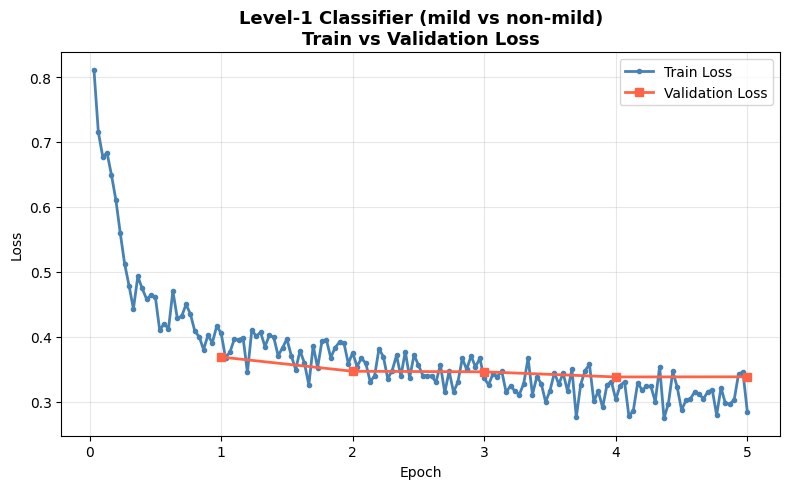

Level-1 loss curve saved ✓


In [ ]:
# ── Level-1: Train vs Validation Loss Curve ───────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_epochs, train_loss,
        label="Train Loss", color="steelblue",
        linewidth=2, marker="o", markersize=3)
ax.plot(eval_epochs, eval_loss,
        label="Validation Loss", color="tomato",
        linewidth=2, marker="s", markersize=6)

ax.set_title("Level-1 Classifier (mild vs non-mild)\nTrain vs Validation Loss",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/ADEGuard/level1_loss_curve.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Level-1 loss curve saved ✓")

In [ ]:
# ── Save Level-1 model ────────────────────────────────────────────────────────
import os

save_l1 = "/content/drive/MyDrive/ADEGuard/severity_l1_final"
os.makedirs(save_l1, exist_ok=True)
trainer_l1.model.save_pretrained(save_l1)
tokenizer.save_pretrained(save_l1)
print("Level-1 model saved ✓")

Level-1 model saved ✓


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# LEVEL-2 CLASSIFIER: moderate vs severe  (non-mild records only)
# ══════════════════════════════════════════════════════════════════════════════

id2label_l2 = {0: "moderate", 1: "severe"}
label2id_l2 = {"moderate": 0, "severe": 1}

print("Building Level-2 model (moderate vs severe)...")
model_l2, device = build_qlora_model(
    num_labels=2,
    id2label=id2label_l2,
    label2id=label2id_l2
)

trainer_l2 = Trainer(
    model=model_l2,
    args=build_training_args(
        "/content/drive/MyDrive/ADEGuard/severity_l2"
    ),
    train_dataset=tokenized_l2["train"],
    eval_dataset=tokenized_l2["validation"],
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

print("\nTraining Level-2 classifier...")
trainer_l2.train()

Building Level-2 model (moderate vs severe)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

8-bit quantization applied ✓


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 591,362 || all params: 108,903,172 || trainable%: 0.5430

Training Level-2 classifier...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.458104,0.438902,0.805441,0.802522,0.805468,0.805441
2,0.477759,0.406843,0.812537,0.809939,0.812552,0.812537
3,0.404480,0.400447,0.814902,0.812407,0.814911,0.814902
4,0.354720,0.416710,0.815494,0.812400,0.816425,0.815494
5,0.354674,0.410967,0.811946,0.809851,0.811388,0.811946


TrainOutput(global_step=4230, training_loss=0.43027568844193265, metrics={'train_runtime': 1609.3203, 'train_samples_per_second': 42.021, 'train_steps_per_second': 2.628, 'total_flos': 8957868513024000.0, 'train_loss': 0.43027568844193265, 'epoch': 5.0})

In [ ]:
# ── Evaluate Level-2 ──────────────────────────────────────────────────────────
preds_l2, labels_l2, _ = trainer_l2.predict(tokenized_l2["test"])
preds_l2 = np.argmax(preds_l2, axis=-1)

print("═" * 50)
print("LEVEL-2 RESULTS: moderate vs severe")
print("═" * 50)
print(classification_report(
    labels_l2, preds_l2,
    target_names=["moderate", "severe"]
))

══════════════════════════════════════════════════
LEVEL-2 RESULTS: moderate vs severe
══════════════════════════════════════════════════
              precision    recall  f1-score   support

    moderate       0.81      0.87      0.84      1000
      severe       0.79      0.70      0.74       691

    accuracy                           0.80      1691
   macro avg       0.80      0.79      0.79      1691
weighted avg       0.80      0.80      0.80      1691



In [ ]:
# ── Level-2: Extract training logs ───────────────────────────────────────────
log_history_l2 = trainer_l2.state.log_history

train_logs_l2 = [(l["epoch"], l["loss"])
                 for l in log_history_l2 if "loss" in l and "eval_loss" not in l]
eval_logs_l2  = [(l["epoch"], l["eval_loss"])
                 for l in log_history_l2 if "eval_loss" in l]

train_epochs_l2 = [x[0] for x in train_logs_l2]
train_loss_l2   = [x[1] for x in train_logs_l2]
eval_epochs_l2  = [x[0] for x in eval_logs_l2]
eval_loss_l2    = [x[1] for x in eval_logs_l2]

print("Train log steps :", len(train_logs_l2))
print("Eval log steps  :", len(eval_logs_l2))

Train log steps : 84
Eval log steps  : 5


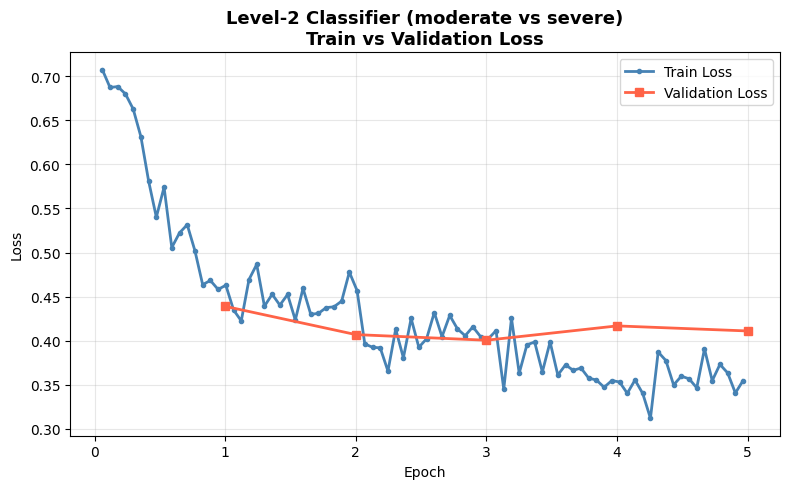

Level-2 loss curve saved ✓


In [ ]:
# ── Level-2: Train vs Validation Loss Curve ───────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_epochs_l2, train_loss_l2,
        label="Train Loss", color="steelblue",
        linewidth=2, marker="o", markersize=3)
ax.plot(eval_epochs_l2, eval_loss_l2,
        label="Validation Loss", color="tomato",
        linewidth=2, marker="s", markersize=6)

ax.set_title("Level-2 Classifier (moderate vs severe)\nTrain vs Validation Loss",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/ADEGuard/level2_loss_curve.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Level-2 loss curve saved ✓")

In [ ]:
# ── Save Level-2 model ────────────────────────────────────────────────────────
save_l2 = "/content/drive/MyDrive/ADEGuard/severity_l2_final"
os.makedirs(save_l2, exist_ok=True)
trainer_l2.model.save_pretrained(save_l2)
tokenizer.save_pretrained(save_l2)
print("Level-2 model saved ✓")

Level-2 model saved ✓


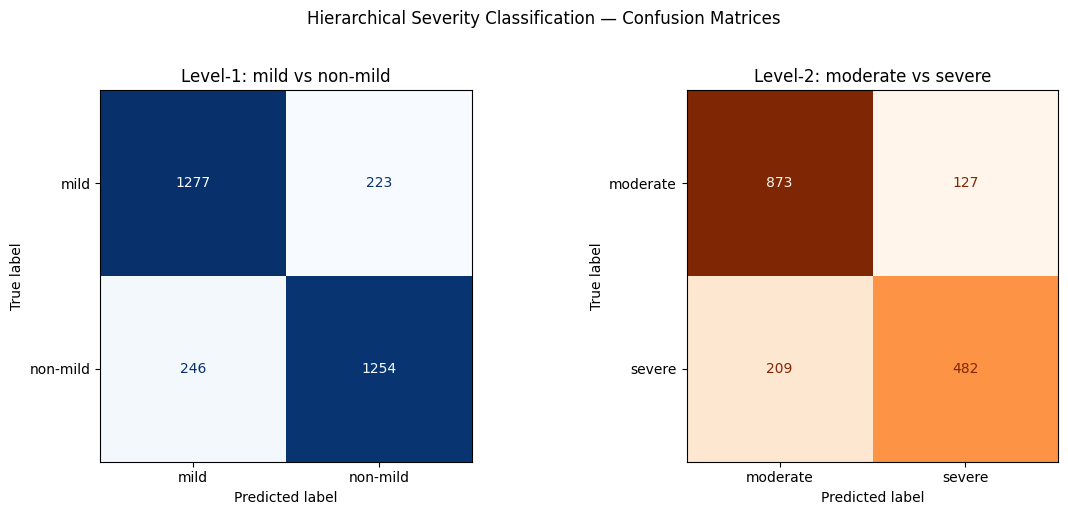

Saved ✓


In [ ]:
# ── Combined confusion matrix for full hierarchy ──────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Level-1
cm1 = confusion_matrix(labels_l1, preds_l1)
ConfusionMatrixDisplay(cm1, display_labels=["mild", "non-mild"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Level-1: mild vs non-mild")

# Level-2
cm2 = confusion_matrix(labels_l2, preds_l2)
ConfusionMatrixDisplay(cm2, display_labels=["moderate", "severe"]).plot(
    ax=axes[1], colorbar=False, cmap="Oranges"
)
axes[1].set_title("Level-2: moderate vs severe")

plt.suptitle("Hierarchical Severity Classification — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ADEGuard/hierarchical_confusion_matrices.png", dpi=150)
plt.show()
print("Saved ✓")